In [18]:
pip install --upgrade matplotlib numpy pillow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: C:\Users\kudom\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


アニメーションを生成し、'bus_animation_manual_route.gif'として保存しています...


IndexError: list index out of range

Error in callback <function _draw_all_if_interactive at 0x00000297AB1D9760> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: x must be a sequence

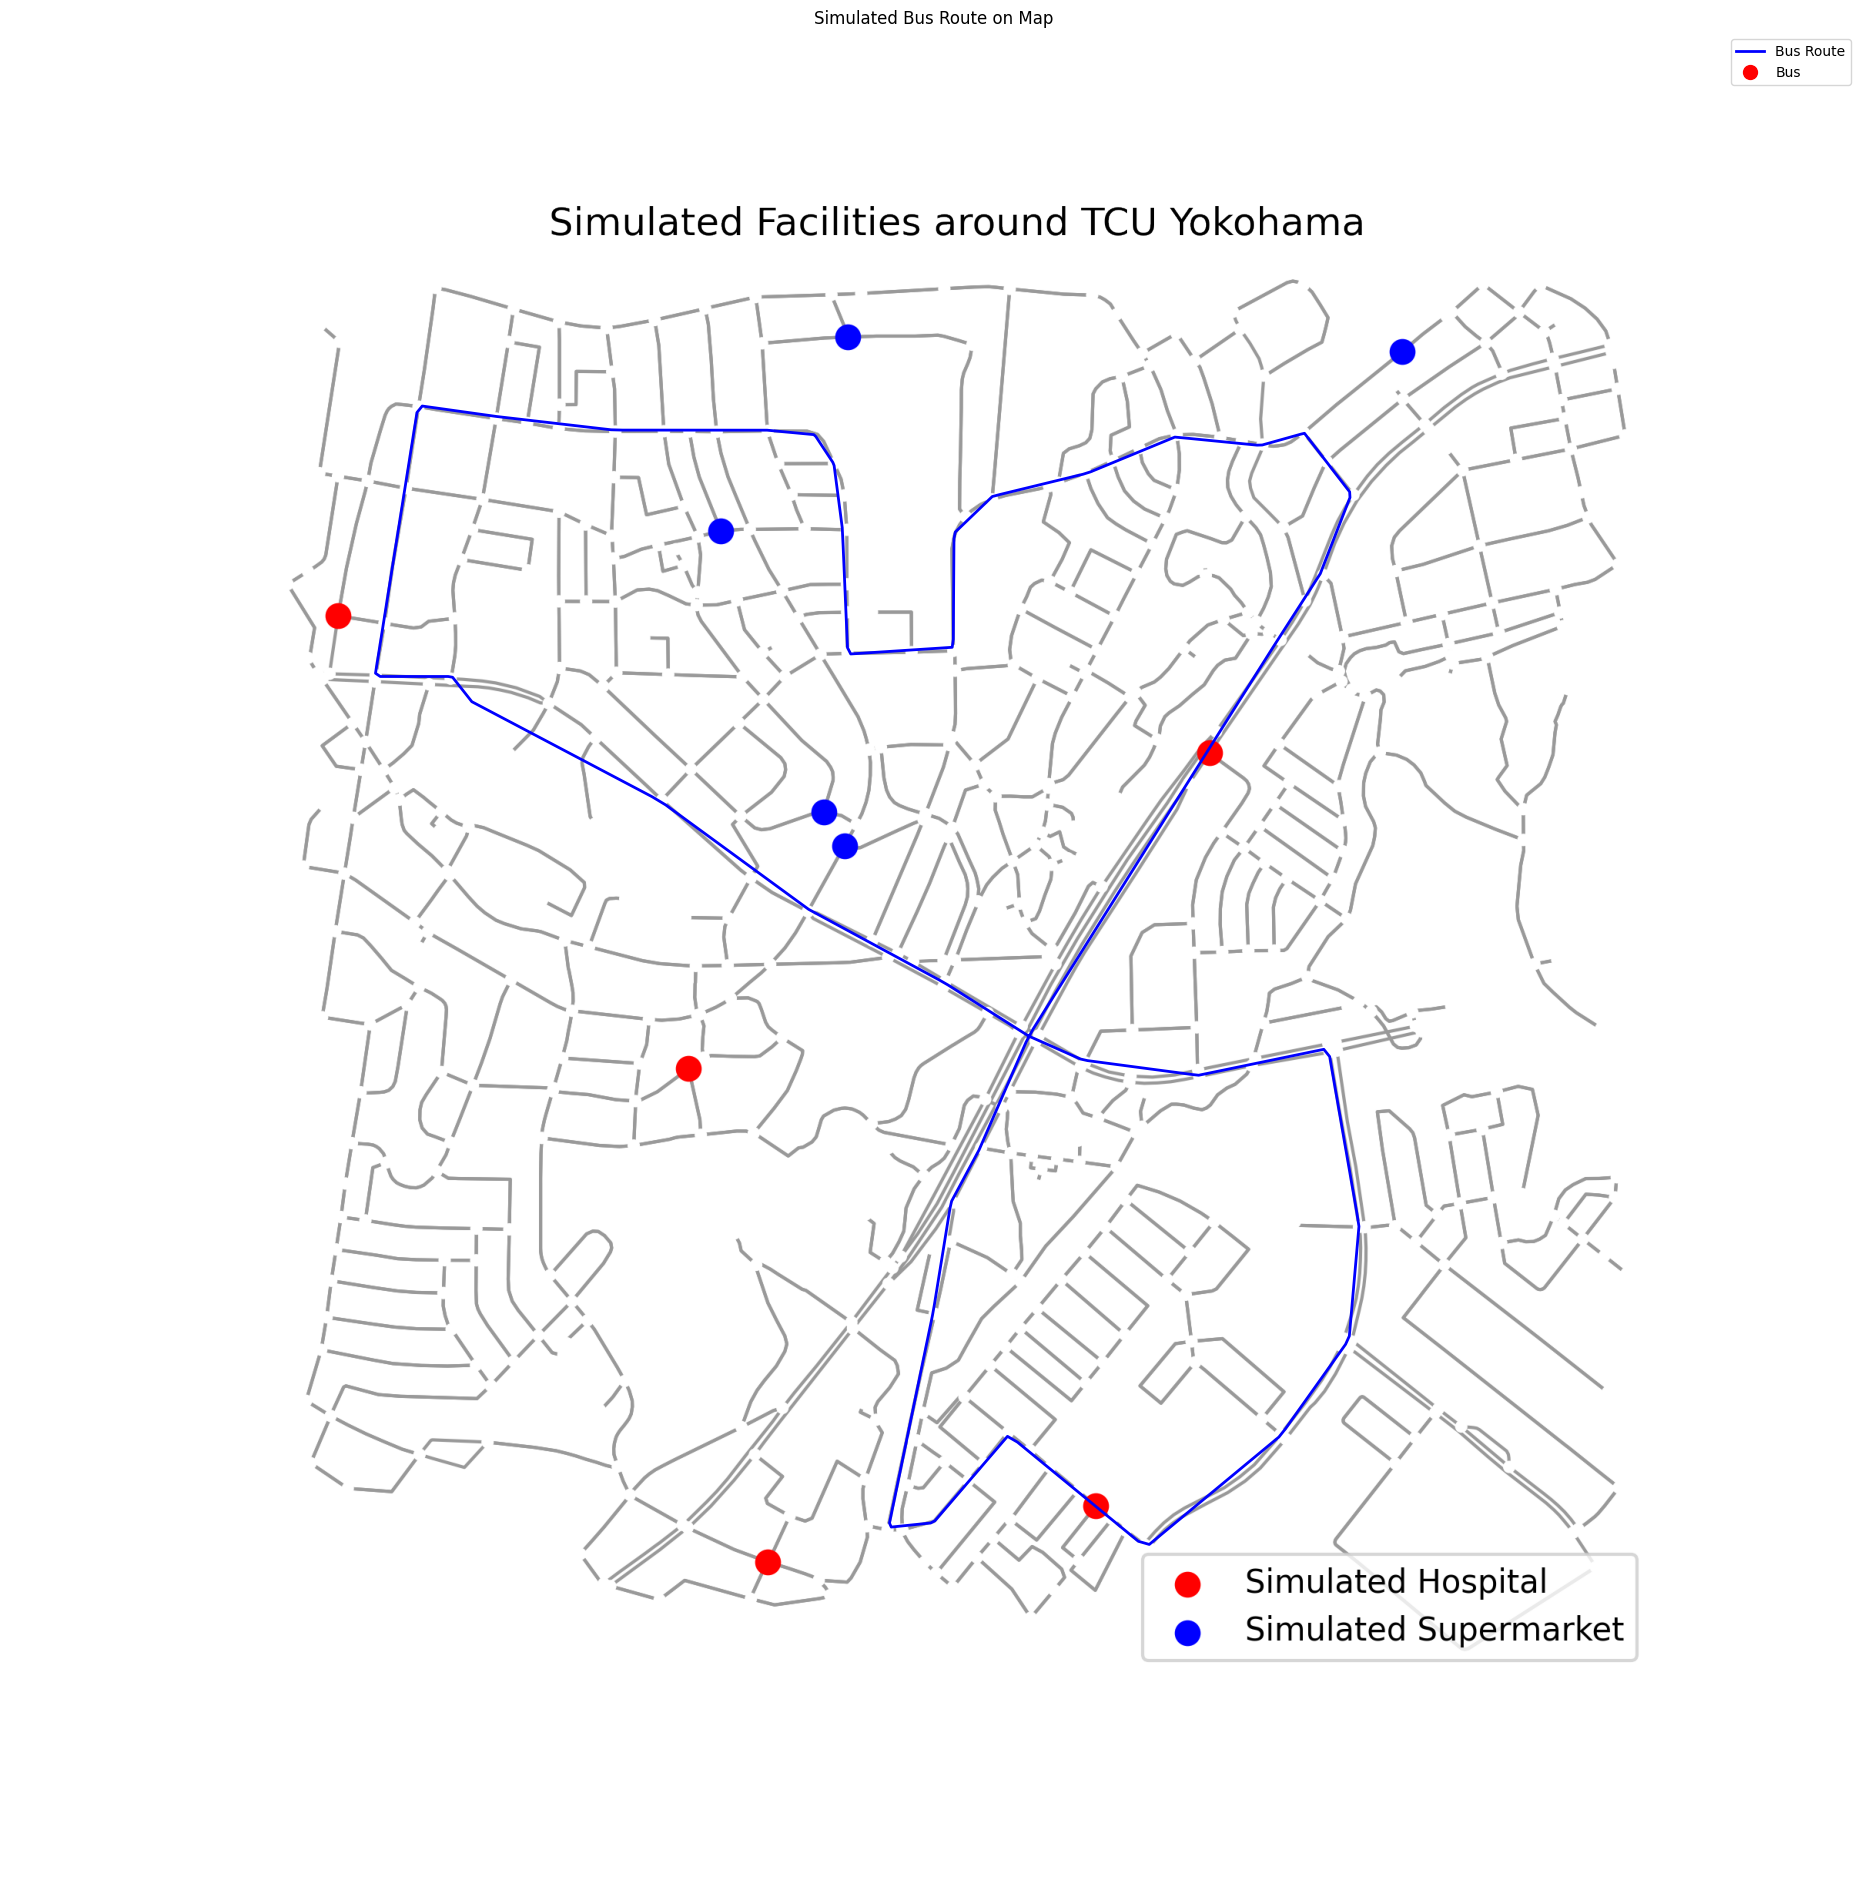

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from PIL import Image

# 1. 地図画像を読み込む
try:
    map_image = Image.open("tcu_map_simulated_facilities_named.png")
except FileNotFoundError:
    print("エラー: 'tcu_map_simulated_facilities_named.png' が見つかりません。")
    exit()

width, height = map_image.size

# 2. 手動で取得した経路の座標を定義する
# ここにメモした座標を正確に入力してください
route_points = np.array([
    [1323, 1304],  # 例: スタート地点
    [1214, 1235],  # 例: 最初の曲がり角
    [1038, 1140],  # 例: 次の曲がり角
    [845, 999],  # 例: さらに次の曲がり角
    [600, 870],
    [574, 837],
    [474, 837],
    [530, 485],
    [629, 499],
    [784, 517],
    [982, 517],
    [1045, 523],
    [1070, 561],
    [1081, 645],
    [1088, 808],
    [1225, 799],
    [1226,651],
    [1276, 603],
    [1399, 573],
    [1513, 526],
    [1624, 537],
    [1681, 521],
    [1742, 600],
    [1702, 703],
    [1646, 790],
    [1528, 977],
    [1323, 1304],
    [1259, 1451],
    [1222, 1520],
    [1199, 1662],
    [1141, 1942],
    [1199, 1936],
    [1297, 1822],
    [1475, 1968],
    [1650, 1823],
    [1739, 1698],
    [1752, 1550],
    [1712, 1320],
    [1543, 1355],
    [1393, 1335],
    [1323, 1304],   # 例: 循環のためにスタート地点に戻る
])

# 3. 経路を滑らかにするために、点と点の間を補間する
num_points = 500
t = np.linspace(0, 1, len(route_points))
t_smooth = np.linspace(0, 1, num_points)

route_x_interp = np.interp(t_smooth, t, route_points[:, 0])
route_y_interp = np.interp(t_smooth, t, route_points[:, 1])

# 4. アニメーションを作成する
fig, ax = plt.subplots(figsize=(width/100, height/100), dpi=100)
ax.imshow(map_image, extent=[0, width, height, 0])

ax.plot(route_x_interp, route_y_interp, color='blue', linestyle='-', linewidth=2, label='Bus Route')

bus_marker, = ax.plot([], [], 'ro', markersize=10, label='Bus')

ax.set_title("Simulated Bus Route on Map")
ax.axis('off')
ax.legend()

def update(frame):
    bus_marker.set_data(route_x_interp[frame], route_y_interp[frame])
    return bus_marker,

# アニメーションを生成
# blit=True を削除します
anim = FuncAnimation(fig, update, frames=num_points, interval=40)

# アニメーションをGIFファイルとして保存
print("アニメーションを生成し、'bus_animation_manual_route.gif'として保存しています...")
anim.save("bus_animation_manual_route.gif", writer='pillow')

print("アニメーションの保存が完了しました。")
plt.close(fig)

RuntimeError: x must be a sequence

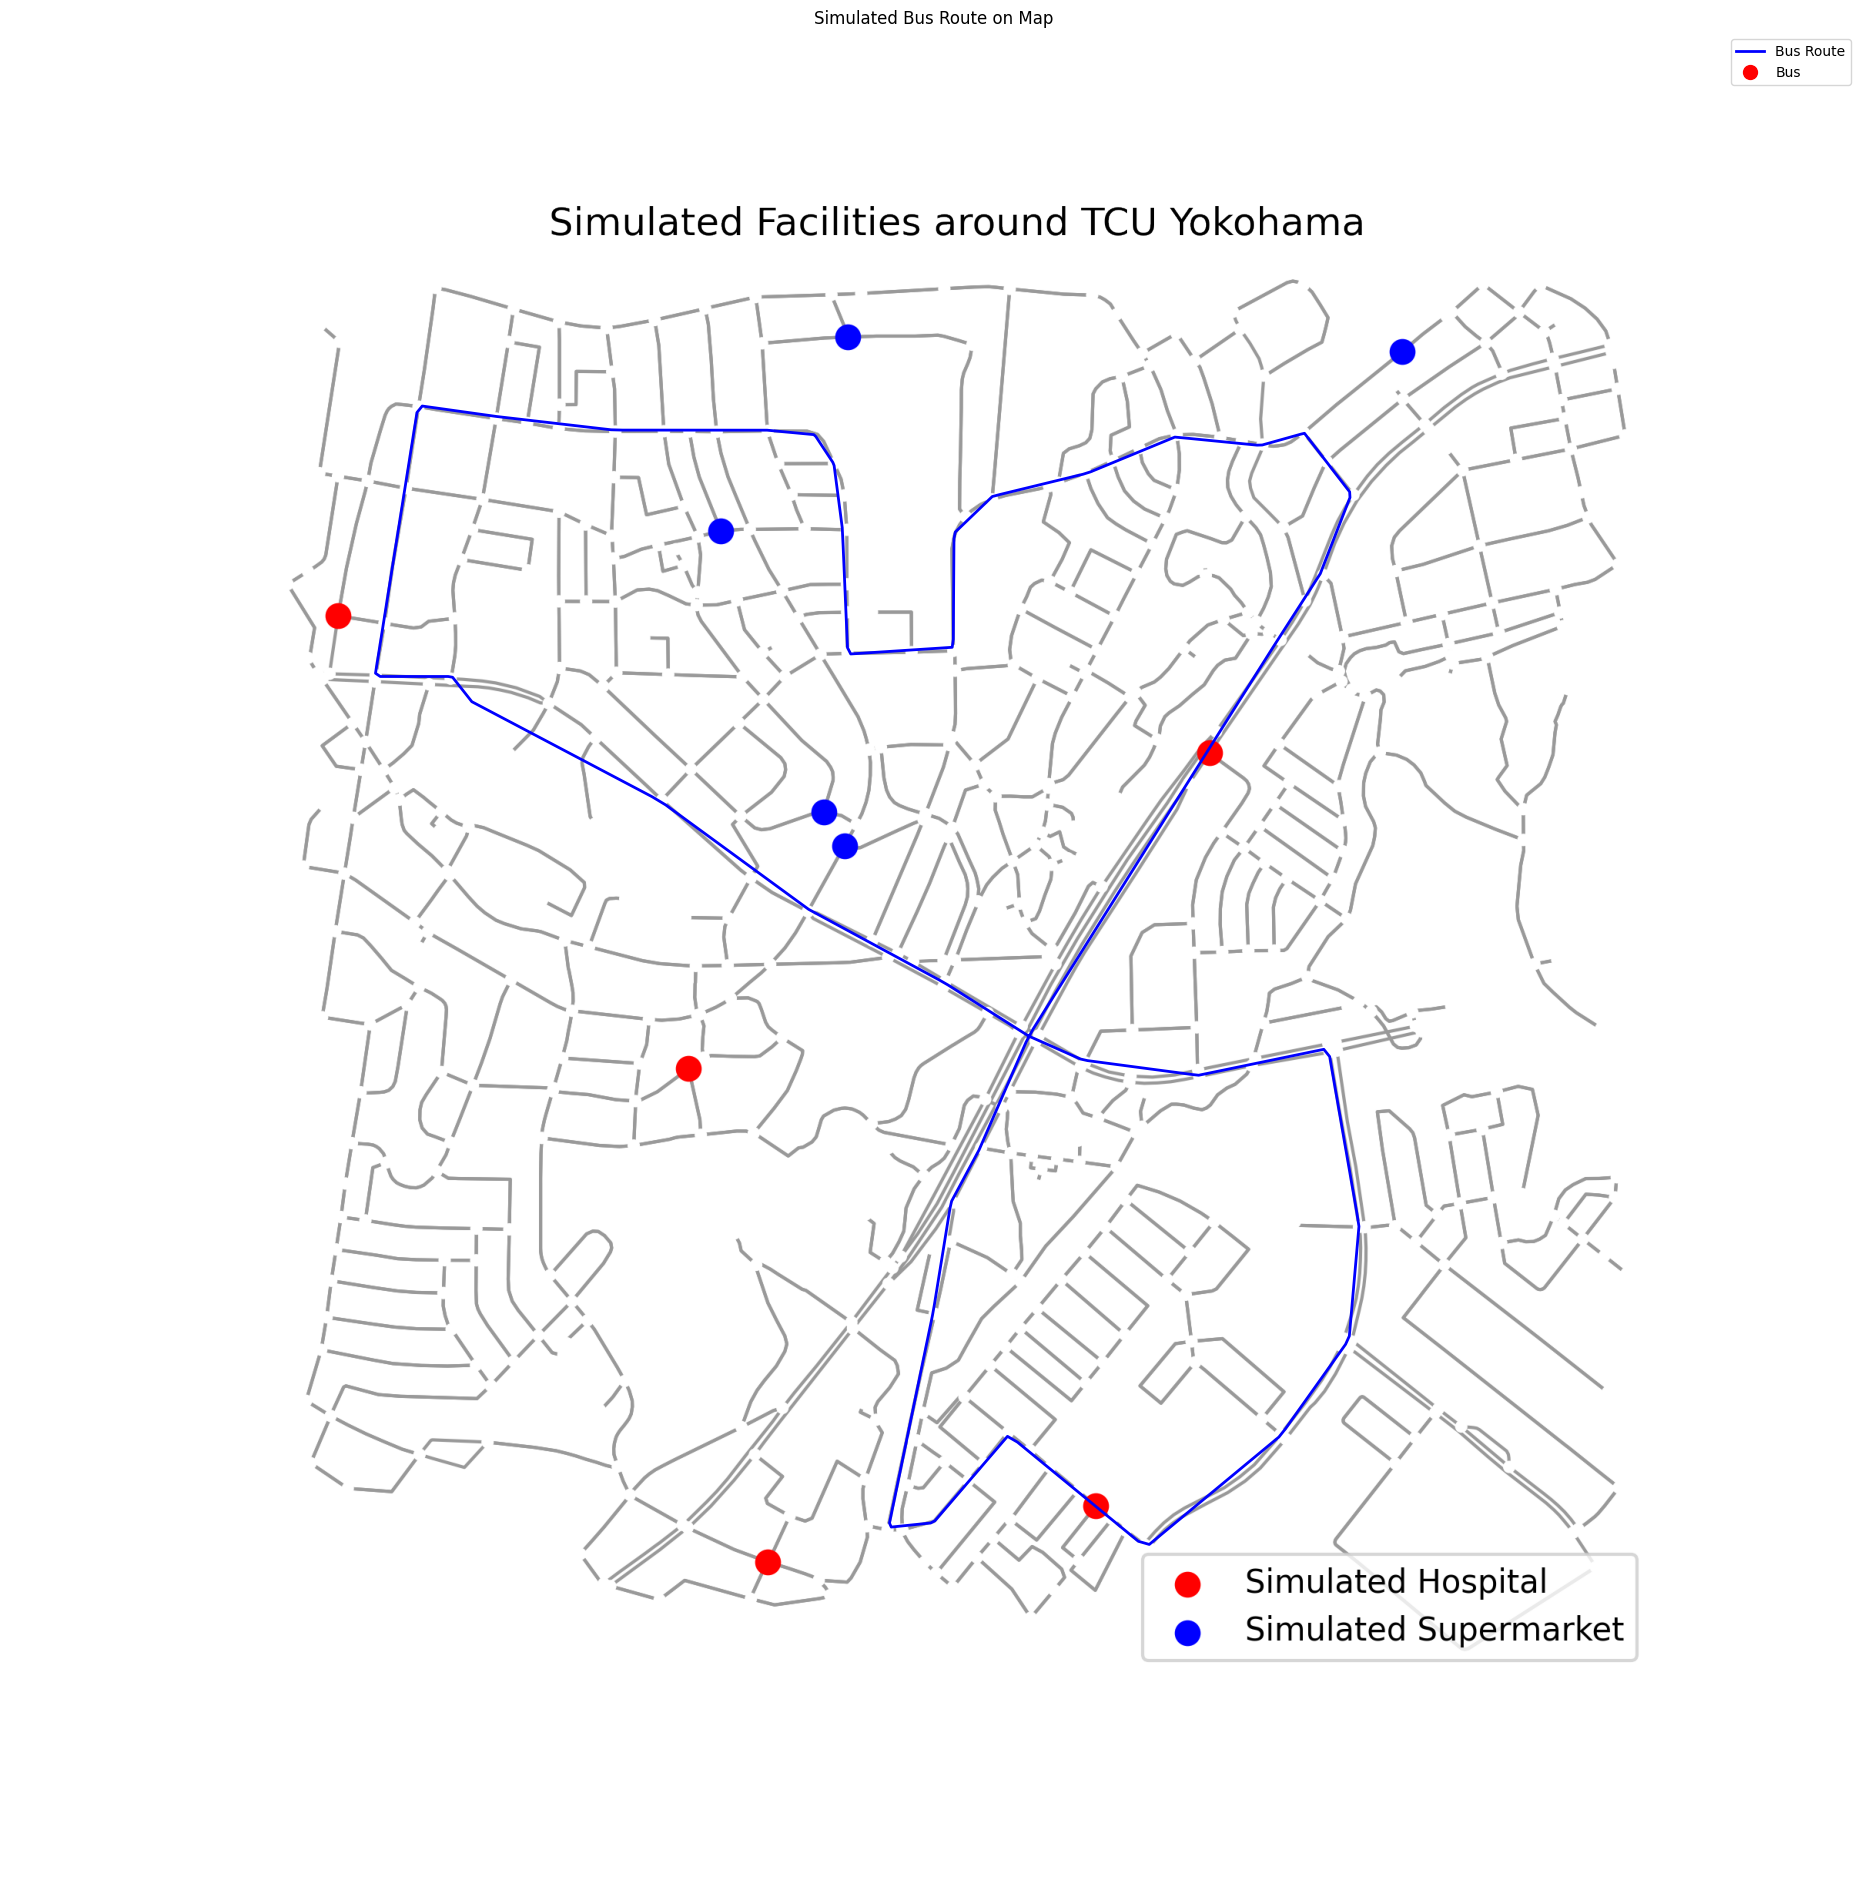

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from PIL import Image

# 1. 地図画像を読み込む
try:
    map_image = Image.open("tcu_map_simulated_facilities_named.png")
except FileNotFoundError:
    print("エラー: 'tcu_map_simulated_facilities_named.png' が見つかりません。")
    exit()

width, height = map_image.size

# 2. 手動で取得した経路の座標を定義する
route_points = np.array([
    [1323, 1304],
    [1214, 1235],
    [1038, 1140],
    [845, 999],
    [600, 870],
    [574, 837],
    [474, 837],
    [530, 485],
    [629, 499],
    [784, 517],
    [982, 517],
    [1045, 523],
    [1070, 561],
    [1081, 645],
    [1088, 808],
    [1225, 799],
    [1226,651],
    [1276, 603],
    [1399, 573],
    [1513, 526],
    [1624, 537],
    [1681, 521],
    [1742, 600],
    [1702, 703],
    [1646, 790],
    [1528, 977],
    [1323, 1304],
    [1259, 1451],
    [1222, 1520],
    [1199, 1662],
    [1141, 1942],
    [1199, 1936],
    [1297, 1822],
    [1475, 1968],
    [1650, 1823],
    [1739, 1698],
    [1752, 1550],
    [1712, 1320],
    [1543, 1355],
    [1393, 1335],
    [1323, 1304],
])

# 3. 経路を滑らかにする
num_points = 500
t = np.linspace(0, 1, len(route_points))
t_smooth = np.linspace(0, 1, num_points)

route_x_interp = np.interp(t_smooth, t, route_points[:, 0])
route_y_interp = np.interp(t_smooth, t, route_points[:, 1])

# 4. アニメーションを作成する
fig, ax = plt.subplots(figsize=(width/100, height/100), dpi=100)
ax.imshow(map_image, extent=[0, width, height, 0])

ax.plot(route_x_interp, route_y_interp, color='blue', linestyle='-', linewidth=2, label='Bus Route')

# 初期描画
bus_marker, = ax.plot([], [], 'ro', markersize=10, label='Bus')

ax.set_title("Simulated Bus Route on Map")
ax.axis('off')
ax.legend()

# アニメーションの更新関数
def update(frame):
    bus_marker.set_data(route_x_interp[frame], route_y_interp[frame])
    return bus_marker,

# アニメーションを生成
# blit=Trueに戻してみます
anim = FuncAnimation(fig, update, frames=num_points, interval=40, blit=True)

# アニメーションを一度画面に表示して、正しく描画されるか確認します
plt.show()

# アニメーションをGIFファイルとして保存
print("アニメーションを生成し、'bus_animation_manual_route.gif'として保存しています...")
anim.save("bus_animation_manual_route.gif", writer='pillow', fps=25)

print("アニメーションの保存が完了しました。")
plt.close(fig)

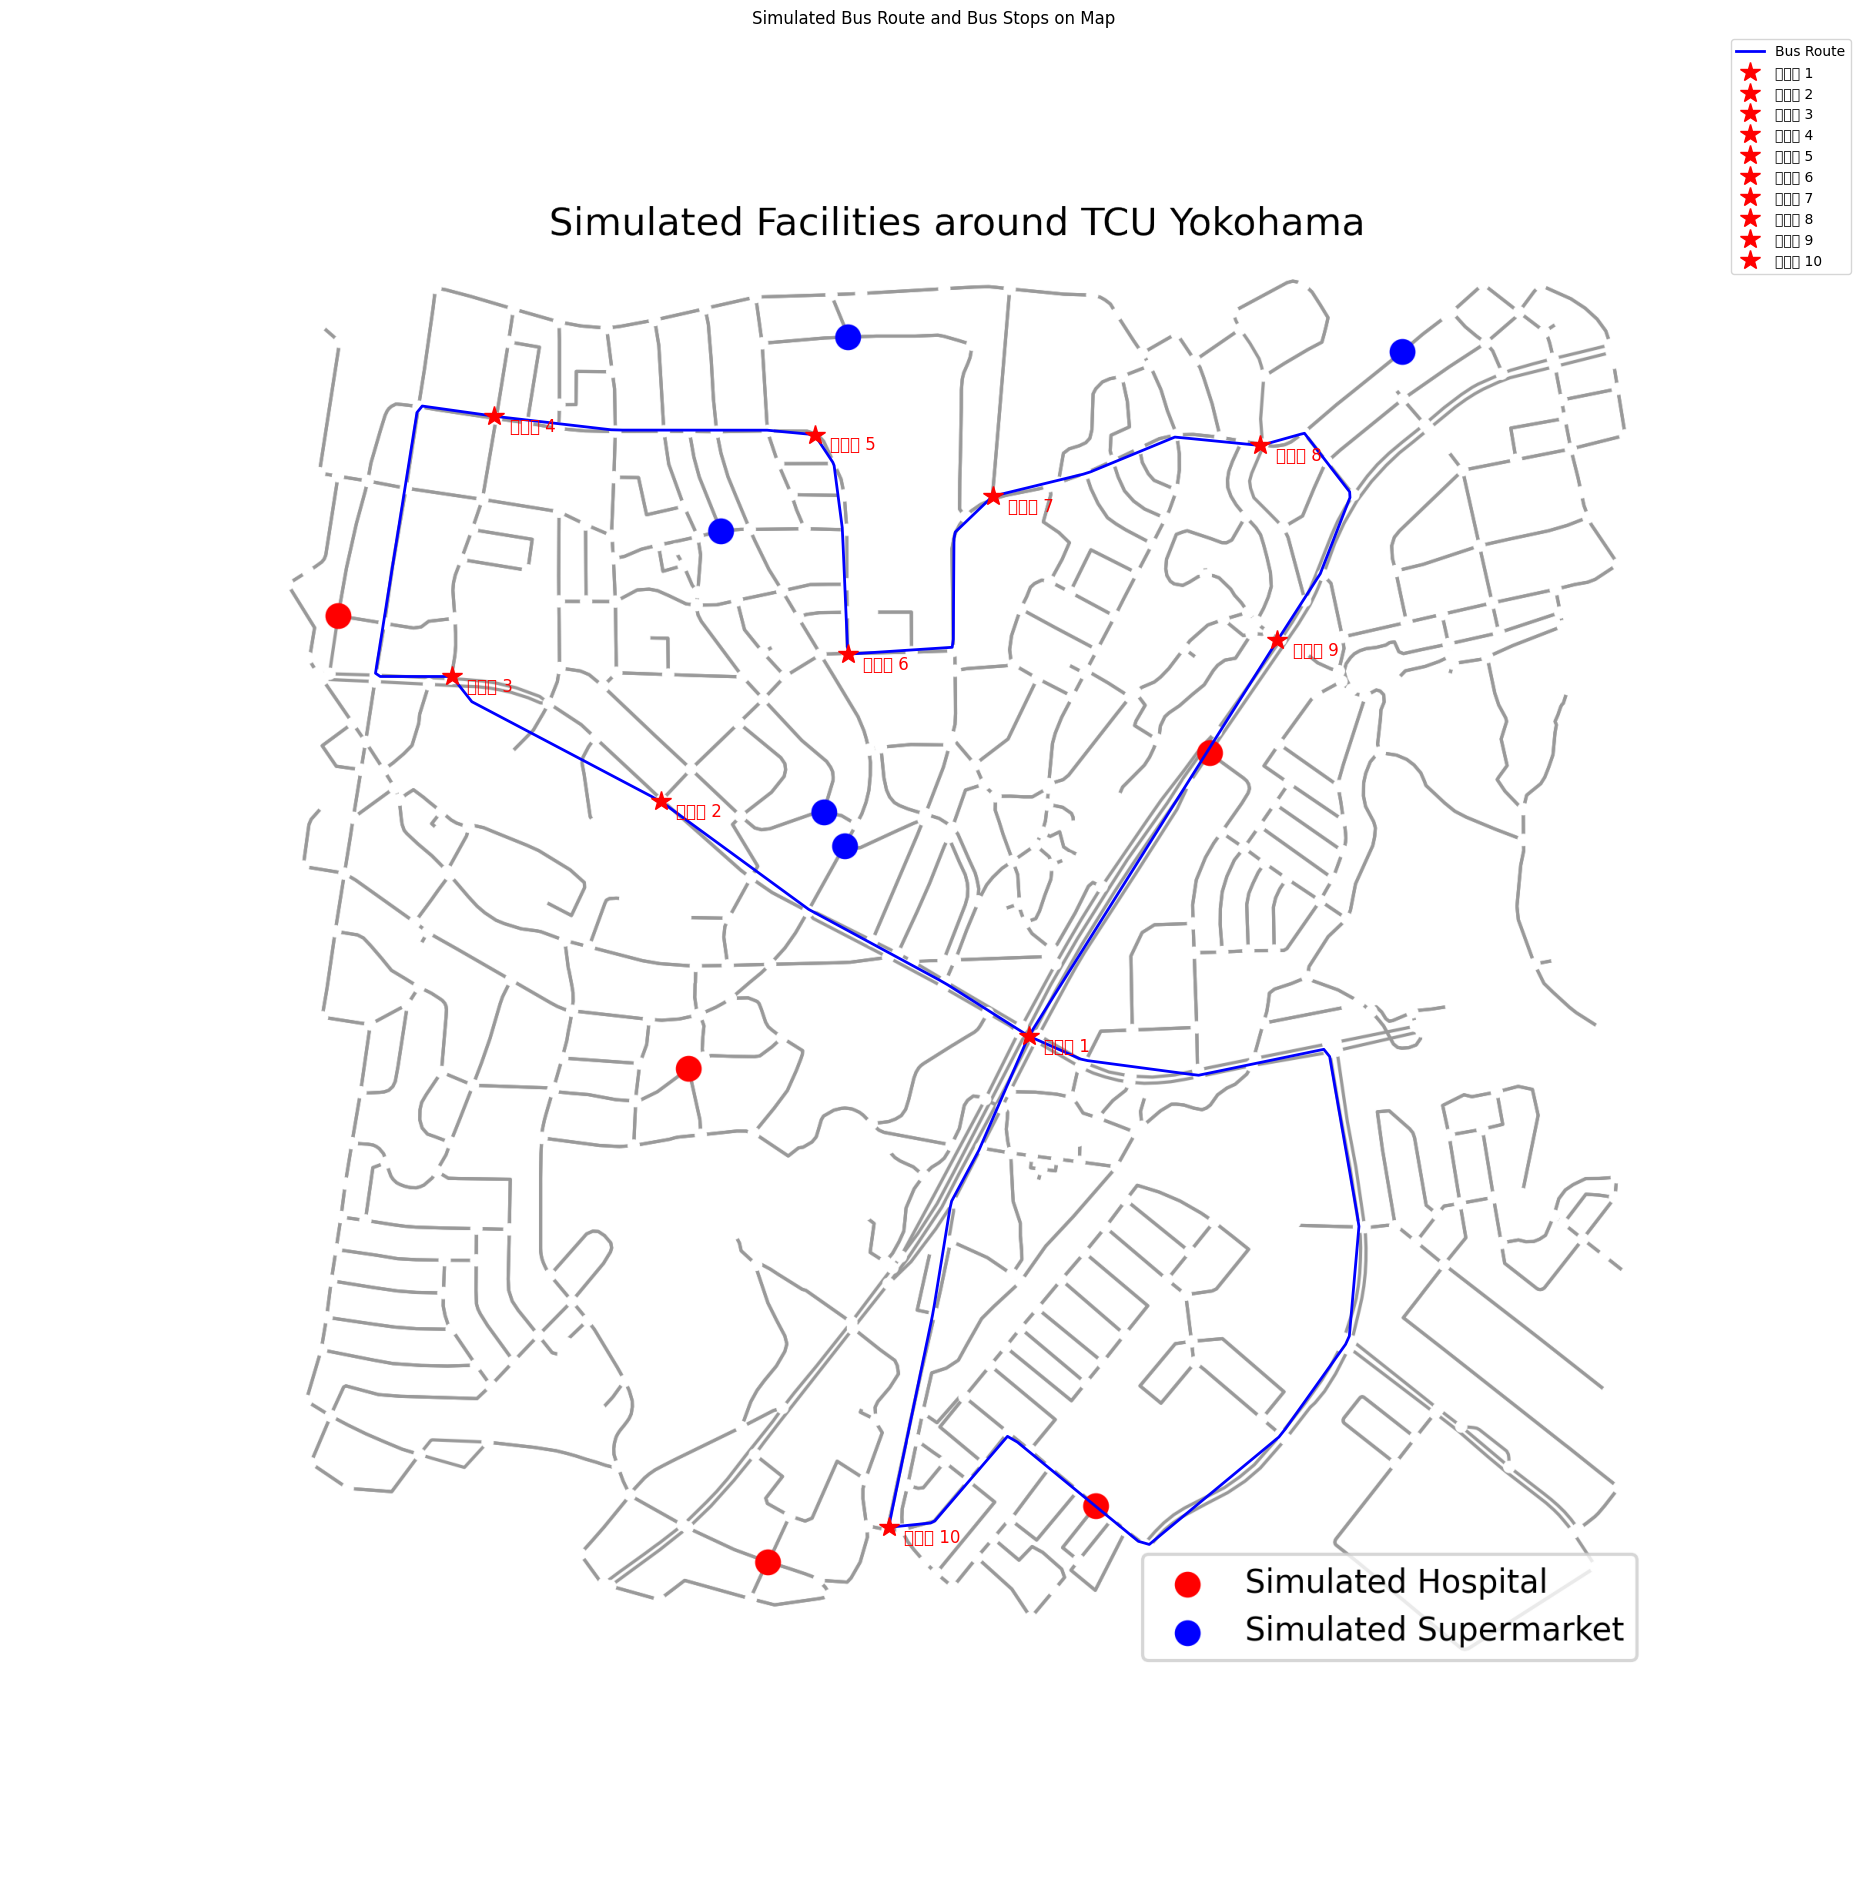

バス経路とバス停のプロットが完了しました。


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. 地図画像を読み込む
try:
    map_image = Image.open("tcu_map_simulated_facilities_named.png")
except FileNotFoundError:
    print("エラー: 'tcu_map_simulated_facilities_named.png' が見つかりません。")
    exit()

width, height = map_image.size

# 2. バス経路の座標を定義する（以前と同じものを使用）
route_points = np.array([
    [1323, 1304],
    [1214, 1235],
    [1038, 1140],
    [845, 999],
    [600, 870],
    [574, 837],
    [474, 837],
    [530, 485],
    [629, 499],
    [784, 517],
    [982, 517],
    [1045, 523],
    [1070, 561],
    [1081, 645],
    [1088, 808],
    [1225, 799],
    [1226, 651],
    [1276, 603],
    [1399, 573],
    [1513, 526],
    [1624, 537],
    [1681, 521],
    [1742, 600],
    [1702, 703],
    [1646, 790],
    [1528, 977],
    [1323, 1304],
    [1259, 1451],
    [1222, 1520],
    [1199, 1662],
    [1141, 1942],
    [1199, 1936],
    [1297, 1822],
    [1475, 1968],
    [1650, 1823],
    [1739, 1698],
    [1752, 1550],
    [1712, 1320],
    [1543, 1355],
    [1393, 1335],
    [1323, 1304],
])

# 3. 経路を滑らかにする
num_points = 500
t = np.linspace(0, 1, len(route_points))
t_smooth = np.linspace(0, 1, num_points)

route_x_interp = np.interp(t_smooth, t, route_points[:, 0])
route_y_interp = np.interp(t_smooth, t, route_points[:, 1])

# 4. 10個のバス停の座標を定義する
bus_stops = {
    'バス停 1': [1323, 1304],
    'バス停 2': [845, 999],
    'バス停 3': [574, 837],
    'バス停 4': [629, 499],
    'バス停 5': [1045, 523],
    'バス停 6': [1088, 808],
    'バス停 7': [1276, 603],
    'バス停 8': [1624, 537],
    'バス停 9': [1646, 790],
    'バス停 10': [1141, 1942]
}

# 5. 地図、経路、バス停をまとめてプロットする
fig, ax = plt.subplots(figsize=(width/100, height/100), dpi=100)
ax.imshow(map_image, extent=[0, width, height, 0])

# バス経路を描画
ax.plot(route_x_interp, route_y_interp, color='blue', linestyle='-', linewidth=2, label='Bus Route')

# 各バス停の座標をプロットし、名前を付ける
for name, coords in bus_stops.items():
    ax.plot(coords[0], coords[1], 'r*', markersize=15, label=name)
    ax.text(coords[0] + 20, coords[1] + 20, name, color='red', fontsize=12)

ax.set_title("Simulated Bus Route and Bus Stops on Map")
ax.axis('off') # 軸の表示をオフにする
ax.legend(loc='upper right')

# プロットされた画像を表示する
plt.show()

print("バス経路とバス停のプロットが完了しました。")